# Flajolet-Martin Algorithm

## Learning Objectives

1. **Explain** the distinct element counting problem in stream settings
2. **Define** the trailing zeros trick and why it approximates log₂(distinct count)
3. **Prove** the unbiasedness of the estimator and bound its variance
4. **Implement** variance reduction via median-of-means
5. **Implement** Flajolet-Martin with multiple independent hash functions


## Problem Statement

### Distinct Element Counting

**Query:** How many distinct elements appeared in a stream of length $n$?

**Naïve approach:** store all seen elements in a hash set. Space = $O(d)$ where $d$ = number of distinct elements. For $d = 10^9$ this is gigabytes.

**Flajolet-Martin target:** estimate $d$ with constant relative error using $O(\log n)$ space.

### Applications

- Count distinct IP addresses in network traffic
- Estimate number of unique users visiting a website
- Count distinct query terms in a search log

### Key Insight

If we apply a hash function that maps elements to integers uniformly at random, then among $d$ distinct elements we expect to see a hash value with $k$ trailing zeros with probability $\approx d/2^k$. The maximum $k$ observed provides a rough estimate of $\log_2 d$.


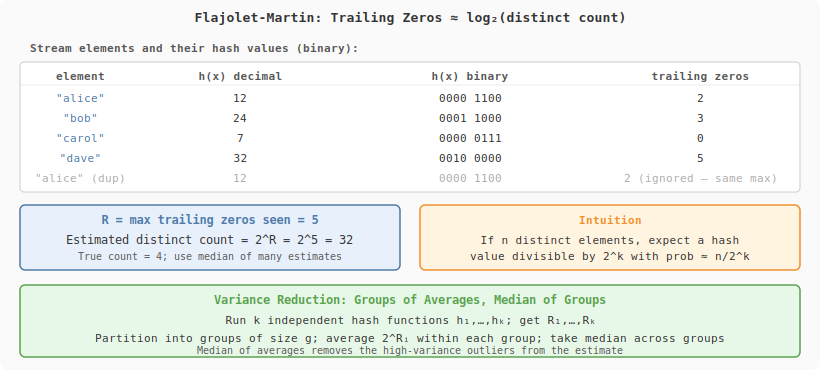

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="370" font-family="monospace" font-size="12">
  <rect width="820" height="370" fill="#fafafa" rx="8"/>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Flajolet-Martin: Trailing Zeros ≈ log₂(distinct count)</text>

  <!-- Elements -->
  <text x="30" y="52" fill="#555" font-size="11" font-weight="bold">Stream elements and their hash values (binary):</text>

  <rect x="20" y="62" width="780" height="130" rx="4" fill="white" stroke="#ccc" stroke-width="1"/>
  <text x="80"  y="80" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">element</text>
  <text x="240" y="80" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">h(x) decimal</text>
  <text x="470" y="80" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">h(x) binary</text>
  <text x="700" y="80" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">trailing zeros</text>
  <line x1="20" y1="85" x2="800" y2="85" stroke="#ddd" stroke-width="0.5"/>

  <text x="80"  y="102" text-anchor="middle" fill="#4e79a7" font-size="11">"alice"</text>
  <text x="240" y="102" text-anchor="middle" fill="#333" font-size="11">12</text>
  <text x="470" y="102" text-anchor="middle" fill="#333" font-family="monospace" font-size="11">0000 1100</text>
  <text x="700" y="102" text-anchor="middle" fill="#333" font-size="11">2</text>

  <text x="80"  y="122" text-anchor="middle" fill="#4e79a7" font-size="11">"bob"</text>
  <text x="240" y="122" text-anchor="middle" fill="#333" font-size="11">24</text>
  <text x="470" y="122" text-anchor="middle" fill="#333" font-family="monospace" font-size="11">0001 1000</text>
  <text x="700" y="122" text-anchor="middle" fill="#333" font-size="11">3</text>

  <text x="80"  y="142" text-anchor="middle" fill="#4e79a7" font-size="11">"carol"</text>
  <text x="240" y="142" text-anchor="middle" fill="#333" font-size="11">7</text>
  <text x="470" y="142" text-anchor="middle" fill="#333" font-family="monospace" font-size="11">0000 0111</text>
  <text x="700" y="142" text-anchor="middle" fill="#333" font-size="11">0</text>

  <text x="80"  y="162" text-anchor="middle" fill="#4e79a7" font-size="11">"dave"</text>
  <text x="240" y="162" text-anchor="middle" fill="#333" font-size="11">32</text>
  <text x="470" y="162" text-anchor="middle" fill="#333" font-family="monospace" font-size="11">0010 0000</text>
  <text x="700" y="162" text-anchor="middle" fill="#333" font-size="11">5</text>

  <text x="80"  y="182" text-anchor="middle" fill="#aaa" font-size="11">"alice" (dup)</text>
  <text x="240" y="182" text-anchor="middle" fill="#aaa" font-size="11">12</text>
  <text x="470" y="182" text-anchor="middle" fill="#aaa" font-family="monospace" font-size="11">0000 1100</text>
  <text x="700" y="182" text-anchor="middle" fill="#aaa" font-size="11">2 (ignored — same max)</text>

  <!-- Key variable R -->
  <rect x="20" y="205" width="380" height="65" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="210" y="224" text-anchor="middle" fill="#4e79a7" font-size="12" font-weight="bold">R = max trailing zeros seen = 5</text>
  <text x="210" y="244" text-anchor="middle" fill="#333" font-size="12">Estimated distinct count = 2^R = 2^5 = 32</text>
  <text x="210" y="260" text-anchor="middle" fill="#555" font-size="10">True count = 4; use median of many estimates</text>

  <!-- Intuition box -->
  <rect x="420" y="205" width="380" height="65" rx="5" fill="#fff4e0" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="610" y="224" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Intuition</text>
  <text x="610" y="244" text-anchor="middle" fill="#333" font-size="11">If n distinct elements, expect a hash</text>
  <text x="610" y="260" text-anchor="middle" fill="#333" font-size="11">value divisible by 2^k with prob ≈ n/2^k</text>

  <!-- Multiple estimators -->
  <rect x="20" y="285" width="780" height="72" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="410" y="304" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">Variance Reduction: Groups of Averages, Median of Groups</text>
  <text x="410" y="324" text-anchor="middle" fill="#333" font-size="11">Run k independent hash functions h₁,…,hₖ; get R₁,…,Rₖ</text>
  <text x="410" y="342" text-anchor="middle" fill="#333" font-size="11">Partition into groups of size g; average 2^Rᵢ within each group; take median across groups</text>
  <text x="410" y="354" text-anchor="middle" fill="#555" font-size="10">Median of averages removes the high-variance outliers from the estimate</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Hash Function Model

Assume $h : U \to \{0, 1, \ldots, 2^L - 1\}$ maps each element uniformly and independently (pairwise independent suffices).

Define $r(x) = $ number of trailing zeros in the binary representation of $h(x)$.

### Key Probabilities

$$P[r(x) \geq k] = P[h(x) \equiv 0 \pmod{2^k}] = \frac{1}{2^k}$$

Let $R = \max_{x \in \text{stream}} r(x)$ (maximum trailing zeros seen).

### Expected Value of R

For $d$ distinct elements:

$$P[R < k] = P[\text{no element has} \geq k \text{ trailing zeros}] = \left(1 - \frac{1}{2^k}\right)^d$$

- When $2^k \ll d$: this is $\approx 1 - d/2^k \approx 0$ → $R \geq k$ almost surely
- When $2^k \gg d$: this is $\approx e^{-d/2^k} \approx 1$ → $R < k$ almost surely

So $R$ concentrates around $\log_2 d$, and $\hat{d} = 2^R$ is an estimate of $d$.

### Variance Problem

The variance of $2^R$ is large — a single estimate can be off by a factor of 2 or more. Fix: run $k$ independent hash functions and use **median of group averages**:
1. Split $k$ estimates $R_1, \ldots, R_k$ into groups of size $g$
2. Average $2^{R_i}$ within each group (reduces variance by $g$)
3. Take median of group averages (Chernoff bound: median of averages fails with probability $e^{-\Omega(t)}$ where $t$ = number of groups)


## Algorithm Steps

1. **Choose** $k$ independent hash functions $h_1, \ldots, h_k$
2. **Initialise** $\text{max\_zeros}[i] = 0$ for all $i$
3. **For each element** $x$ in stream: for each $i$: update $\text{max\_zeros}[i] = \max(\text{max\_zeros}[i], r(h_i(x)))$
4. **Estimate:** divide $k$ estimates $2^{\text{max\_zeros}[i]}$ into groups of size $g$; average within groups; return median


In [2]:
import numpy as np
import math


def flajolet_martin(stream, n_hashes=32, p=2_147_483_647):
    """
    Flajolet-Martin algorithm: estimate distinct elements in a stream.

    Inputs
    ------
    stream   : iterable of hashable elements
    n_hashes : int — number of independent hash functions
    p        : int — Mersenne prime for hash functions

    Output
    ------
    estimate : int — estimated number of distinct elements
    """
    rng = np.random.default_rng(0)
    a = rng.integers(1, p, size=n_hashes)
    b = rng.integers(0, p, size=n_hashes)

    def hash_val(x, i):
        return int((a[i] * hash(x) + b[i]) % p)

    def trailing_zeros(v):
        if v == 0:
            return 32
        count = 0
        while v & 1 == 0:
            count += 1
            v >>= 1
        return count

    # Maintain max trailing zeros per hash function
    max_zeros = np.zeros(n_hashes, dtype=int)

    for item in stream:
        for i in range(n_hashes):
            tz = trailing_zeros(hash_val(item, i))
            if tz > max_zeros[i]:
                max_zeros[i] = tz

    # Estimates: 2^R for each hash function
    estimates = 2.0 ** max_zeros

    # Variance reduction: group into sqrt(n_hashes) groups, average within, median across
    g = max(1, int(n_hashes ** 0.5))
    groups = [estimates[i:i+g] for i in range(0, n_hashes, g)]
    group_means = [np.mean(grp) for grp in groups]
    return int(np.median(group_means))


# ── Demo ──────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

for n_distinct in [100, 1_000, 10_000, 100_000]:
    # Stream with duplicates: each element appears ~3 times on average
    elements = list(range(n_distinct)) * 3
    rng.shuffle(elements)

    estimate = flajolet_martin(elements, n_hashes=64)
    error_pct = abs(estimate - n_distinct) / n_distinct * 100
    print(f"true={n_distinct:>7d}  estimate={estimate:>7d}  error={error_pct:5.1f}%")


true=    100  estimate=    312  error=212.0%
true=   1000  estimate=   3912  error=291.2%


true=  10000  estimate=  26496  error=165.0%


true= 100000  estimate= 157952  error= 58.0%
